In [1]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
import pandas as pd

# For interpolation
from scipy.interpolate import RectBivariateSpline, interp2d

import warnings

# Ignore DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*divmax.*")

import logging
# Basic registry settings
logging.basicConfig(level=logging.INFO)

import Cosmo_util_data as cu

# Parametros fiduciales

Omega_b0_fid = 0.05
Omega_m0_fid = 0.32
h_fid = 0.67
ns_fid = 0.96
sigma8_fid = 0.816
Omega_DE0_fid = 0.68
w0_fid = -1.0
wa_fid = 0.0
gamma_fid = 0.55

#c = 9.72 * 10 ** (-15) # en Mpc
c = 300000 #en km/s
Aia = 1.72
Cia = 0.0134
nia = -0.41
bia = 2.17

# ---- ANOTHER PARAMETERS

f_out = 0.1
c_b = 1.0
z_b = 0.0
sigma_b = 0.05
c_o = 1.0
z_o = 0.1
sigma_o = 0.05

In [2]:
import Cosmo_integration as ci

In [161]:
zs = np.linspace(0.001, 2.5, 20)#np.logspace(np.log10(0.001), np.log10(2.5), 20)
params = {'z': zs, 'model' : 'ACDM_flat'}
    
A = ci.CosmoIntegration(params)

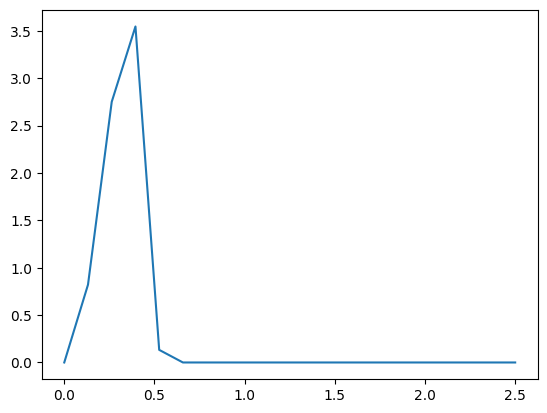

In [162]:
n_i = np.array([A.n_i_try(0, z) for z in zs]) 

plt.plot(zs, n_i)

In [163]:
n_i

array([2.75549529e-005, 8.21303153e-001, 2.75176735e+000, 3.54717810e+000,
       1.33171275e-001, 1.05220900e-005, 9.54082446e-013, 8.74248220e-023,
       7.80311601e-036, 6.69943001e-052, 5.50963003e-071, 4.33654948e-093,
       3.26845948e-118, 2.36168025e-146, 1.63824387e-177, 1.09253171e-211,
       7.01432521e-249, 4.34104668e-289, 0.00000000e+000, 0.00000000e+000])

In [190]:
def n_t(z):
    z_m, z_0 = 0.9, 0.9 / np.sqrt(2)
    return ((z / z_0)**2) * np.exp(-(z / z_0)**(3 / 2))

def p_ph(z_p, z):
    def p_ph_unormalizate(z_p, z):
        # Calcula el valor no normalizado (fórmula exacta del paper)
        first = ((1 - f_out) / (np.sqrt(2 * np.pi) * sigma_b * (1+z))) * np.exp(- 0.5 * (((z - c_b*z_p - z_b) / (sigma_b * (1+z)))**2))
        second = (f_out / (np.sqrt(2 * np.pi) * sigma_o * (1+z))) * np.exp(- 0.5 * (((z - c_o*z_p - z_o) / (sigma_o * (1+z)))**2))
        unnormalized = first + second
        return unnormalized
    def normalization(z_p, z):
        delta = z_p[1] - z_p[0]
        A = np.array([p_ph_unormalizate(zs, z) for zs in z_p]) * delta
        return np.sum(A)
        
    return p_ph_unormalizate(z_p, z) / normalization(z_p, z)

def n_i_try(i, z):
    '''
    This function calculates the numerator for the window function for bin i.
    It uses the redshift bins defined in the original code and the n_t and p_ph functions.
    The function is normalized
    '''
    z_bins = [0.001, 0.42, 0.56, 0.68, 0.79, 0.9, 1.02, 1.15, 1.32, 1.58, 2.5]
    denominators = np.array([0.04690055617199938, 0.041209323920287824, 0.04169211292551454, 0.040191768918692396, 0.03953241118138398, 0.040135711830953276, 0.038169468867739365, 0.04019519620236196, 0.04114271877029161, 0.039251552948857606])

    def numerator_n_i(i, z):
        z_prime = np.linspace(z_bins[i], z_bins[i + 1], 50)
        delta = z_prime[1] - z_prime[0]
        multiplication_array = n_t(z) * p_ph(z_prime, z)
        result = np.sum(multiplication_array * delta)
        return float(result)
     #def denominator(i):
        z_prime = np.linspace(z_bins[0], z_bins[-1], 30)
        delta = (z_prime[-1] - z_prime[0]) / len(z_prime)
        num = np.array([numerator_n_i(i, z_p) for z_p in z_prime])
        deno = float(np.sum(num) * delta)
        print(deno)
        return deno

    return numerator_n_i(i, z)/ denominators[i]

In [191]:
delta = zs[1] - zs[0]
n_i = np.array([n_i_try(0, z) for z in zs]) * delta
print(sum(n_i))

9.021039850183993


In [165]:
r = A.r(1, Omega_m0_fid, h_fid, Omega_b0_fid, Omega_DE0_fid, w0_fid, wa_fid, ns_fid, sigma8_fid, gamma_fid)

0.32 0.67 0.05 0.68 -1.0 0.0 0.96 0.816 0.55


In [166]:
r

np.float64(3416.4427115659796)

In [167]:
W = A.Window2(0, Omega_m0_fid, h_fid, Omega_b0_fid, Omega_DE0_fid, w0_fid, wa_fid, ns_fid, sigma8_fid, gamma_fid)

In [168]:
W

array([9.03972810e-001, 4.64834216e-001, 1.50480597e-001, 1.21950718e-002,
       1.48293849e-005, 4.34374398e-011, 2.19482177e-019, 1.77381680e-030,
       2.22973587e-044, 4.30070349e-061, 1.26218607e-080, 5.59790105e-103,
       3.72420488e-128, 3.68045982e-156, 5.32371311e-187, 1.09953203e-220,
       3.09450120e-257, 1.06970803e-296, 0.00000000e+000, 0.00000000e+000])

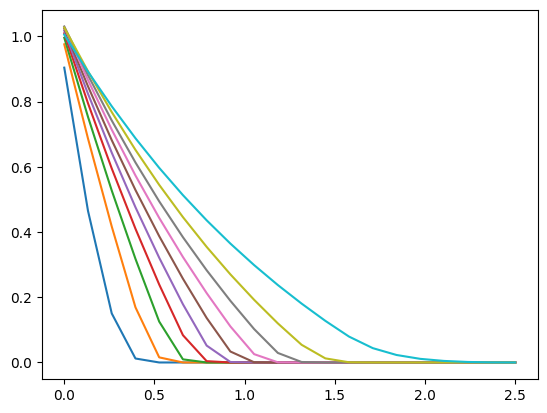

In [169]:
for i in range(10):
    W = A.Window2(i, Omega_m0_fid, h_fid, Omega_b0_fid, Omega_DE0_fid, w0_fid, wa_fid, ns_fid, sigma8_fid, gamma_fid)
    plt.plot(zs, W)

In [170]:
p = np.sum(A.p_ph(zs, 0.001) * (2.5 - 0.001) / 20)

In [171]:
p

np.float64(1.0282970368319158)

In [172]:
def p_ph(z_p, z):
    first = ((1 - f_out) / (np.sqrt(2 * np.pi) * sigma_b * (1+z))) * np.exp(- 0.5 * (((z - c_b*z_p - z_b) / (sigma_b * (1+z)))**2))
    second = (f_out / (np.sqrt(2 * np.pi) * sigma_o * (1+z))) * np.exp(- 0.5 * (((z - c_o*z_p - z_o) / (sigma_o * (1+z)))**2))
    return first + second


In [173]:
def p_ph_2(z_p, z):
    def p_ph_unormalizate(z_p, z):
        # Calcula el valor no normalizado (fórmula exacta del paper)
        first = ((1 - f_out) / (np.sqrt(2 * np.pi) * sigma_b * (1+z))) * np.exp(- 0.5 * (((z - c_b*z_p - z_b) / (sigma_b * (1+z)))**2))
        second = (f_out / (np.sqrt(2 * np.pi) * sigma_o * (1+z))) * np.exp(- 0.5 * (((z - c_o*z_p - z_o) / (sigma_o * (1+z)))**2))
        unnormalized = first + second
        return unnormalized
    def normalization(z_p, z):
        delta = z_p[1] - z_p[0]
        A = np.array([p_ph_unormalizate(zs, z) for zs in z_p]) * delta
        return np.sum(A)
    
    return p_ph_unormalizate(z_p, z) / normalization(z_p, z)

In [174]:
zs = np.linspace(0.001, 2.5, 20)

In [175]:
delta = (max(zs) - min(zs)) / len(zs)
print(delta)
delta_2 = zs[1] - zs[0]
print(delta_2)
p = np.sum(p_ph_2(zs, 0.001) * delta_2)

0.12495
0.13152631578947369


In [177]:
p

np.float64(1.0)